<a href="https://colab.research.google.com/github/Vickayo04/Machine_Learning-Projects/blob/main/ChurnPrediction_Challenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import pickle

Data Loading and Understanding

In [14]:
df = pd.read_csv("/content/train.csv")

In [15]:
df.shape

(243787, 21)

In [16]:
df.head()

,AccountAge,MonthlyCharges,TotalCharges,SubscriptionType,PaymentMethod,PaperlessBilling,ContentType,MultiDeviceAccess,DeviceRegistered,ViewingHoursPerWeek,...,ContentDownloadsPerMonth,GenrePreference,UserRating,SupportTicketsPerMonth,Gender,WatchlistSize,ParentalControl,SubtitlesEnabled,CustomerID,Churn
0,20,11.055215,221.104302,Premium,Mailed check,No,Both,No,Mobile,36.758104,...,10,Sci-Fi,2.176498,4,Male,3,No,No,CB6SXPNVZA,0
1,57,5.175208,294.986882,Basic,Credit card,Yes,Movies,No,Tablet,32.450568,...,18,Action,3.478632,8,Male,23,No,Yes,S7R2G87O09,0
2,73,12.106657,883.785952,Basic,Mailed check,Yes,Movies,No,Computer,7.395160,...,23,Fantasy,4.238824,6,Male,1,Yes,Yes,EASDC20BDT,0
3,32,7.263743,232.439774,Basic,Electronic check,No,TV Shows,No,Tablet,27.960389,...,30,Drama,4.276013,2,Male,24,Yes,Yes,NPF69NT69N,0
4,57,16.953078,966.325422,Premium,Electronic check,Yes,TV Shows,No,TV,20.083397,...,20,Comedy,3.616170,4,Female,0,No,No,4LGYPK7VOL,0


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243787 entries, 0 to 243786
Data columns (total 21 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   AccountAge                243787 non-null  int64  
 1   MonthlyCharges            243787 non-null  float64
 2   TotalCharges              243787 non-null  float64
 3   SubscriptionType          243787 non-null  object 
 4   PaymentMethod             243787 non-null  object 
 5   PaperlessBilling          243787 non-null  object 
 6   ContentType               243787 non-null  object 
 7   MultiDeviceAccess         243787 non-null  object 
 8   DeviceRegistered          243787 non-null  object 
 9   ViewingHoursPerWeek       243787 non-null  float64
 10  AverageViewingDuration    243787 non-null  float64
 11  ContentDownloadsPerMonth  243787 non-null  int64  
 12  GenrePreference           243787 non-null  object 
 13  UserRating                243787 non-null  f

In [18]:
df = df.drop(columns=['CustomerID'])

In [19]:
df.head()

,AccountAge,MonthlyCharges,TotalCharges,SubscriptionType,PaymentMethod,PaperlessBilling,ContentType,MultiDeviceAccess,DeviceRegistered,ViewingHoursPerWeek,AverageViewingDuration,ContentDownloadsPerMonth,GenrePreference,UserRating,SupportTicketsPerMonth,Gender,WatchlistSize,ParentalControl,SubtitlesEnabled,Churn
0,20,11.055215,221.104302,Premium,Mailed check,No,Both,No,Mobile,36.758104,63.531377,10,Sci-Fi,2.176498,4,Male,3,No,No,0
1,57,5.175208,294.986882,Basic,Credit card,Yes,Movies,No,Tablet,32.450568,25.725595,18,Action,3.478632,8,Male,23,No,Yes,0
2,73,12.106657,883.785952,Basic,Mailed check,Yes,Movies,No,Computer,7.395160,57.364061,23,Fantasy,4.238824,6,Male,1,Yes,Yes,0
3,32,7.263743,232.439774,Basic,Electronic check,No,TV Shows,No,Tablet,27.960389,131.537507,30,Drama,4.276013,2,Male,24,Yes,Yes,0
4,57,16.953078,966.325422,Premium,Electronic check,Yes,TV Shows,No,TV,20.083397,45.356653,20,Comedy,3.616170,4,Female,0,No,No,0


In [20]:
print(df["Churn"].value_counts())

Churn
0    199605
1     44182
Name: count, dtype: int64


**Exploratory Data Analysis (EDA)**

In [21]:
df.describe()

,AccountAge,MonthlyCharges,TotalCharges,ViewingHoursPerWeek,AverageViewingDuration,ContentDownloadsPerMonth,UserRating,SupportTicketsPerMonth,WatchlistSize,Churn
count,243787.000000,243787.000000,243787.000000,243787.000000,243787.000000,243787.000000,243787.000000,243787.000000,243787.000000,243787.000000
mean,60.083758,12.490695,750.741017,20.502179,92.264061,24.503513,3.002713,4.504186,12.018508,0.181232
std,34.285143,4.327615,523.073273,11.243753,50.505243,14.421174,1.155259,2.872548,7.193034,0.385211
min,1.000000,4.990062,4.991154,1.000065,5.000547,0.000000,1.000007,0.000000,0.000000,0.000000
25%,30.000000,8.738543,329.147027,10.763953,48.382395,12.000000,2.000853,2.000000,6.000000,0.000000
50%,60.000000,12.495555,649.878487,20.523116,92.249992,24.000000,3.002261,4.000000,12.000000,0.000000
75%,90.000000,16.238160,1089.317362,30.219396,135.908048,37.000000,4.002157,7.000000,18.000000,0.000000
max,119.000000,19.989957,2378.723844,39.999723,179.999275,49.000000,4.999989,9.000000,24.000000,1.000000


In [22]:
df.columns

Index(['AccountAge', 'MonthlyCharges', 'TotalCharges', 'SubscriptionType',
       'PaymentMethod', 'PaperlessBilling', 'ContentType', 'MultiDeviceAccess',
       'DeviceRegistered', 'ViewingHoursPerWeek', 'AverageViewingDuration',
       'ContentDownloadsPerMonth', 'GenrePreference', 'UserRating',
       'SupportTicketsPerMonth', 'Gender', 'WatchlistSize', 'ParentalControl',
       'SubtitlesEnabled', 'Churn'],
      dtype='object')

**Numerical Feautures analysis**

Understand the distribution of the numerical features.

In [23]:
def plot_histogram(df, column_name):

  plt.figure(figsize=(6, 6))
  sns.histplot(data=df, x=column_name, kde=True)
  plt.title(f"Distribution of {column_name}")
  plt.xlabel(column_name)
  plt.ylabel("Frequency")
  plt.show()

  #Calculate the mean aadn median values
  col_mean = df[column_name].mean()
  col_median = df[column_name].median()

  print(f"Mean of {column_name}: {col_mean}")
  print(f"Median of {column_name}: {col_median}")

#add vertical lines for the mean and median
  plt.axvline(col_mean, color='red', linestyle='dashed', linewidth=2, label='Mean')
  plt.axvline(col_median, color='green', linestyle='dashed', linewidth=2, label='Median')
  plt.legend()

  plt.show()

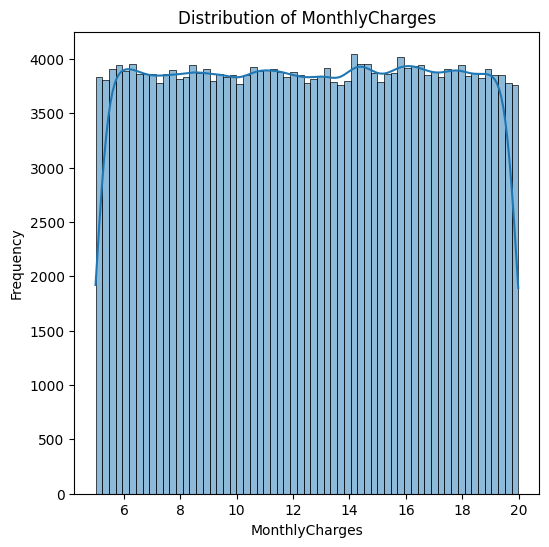

Mean of MonthlyCharges: 12.49069450621346
Median of MonthlyCharges: 12.49555523401009


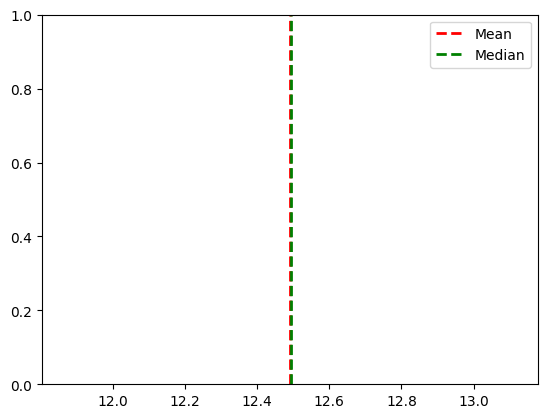

In [24]:
plot_histogram(df, 'MonthlyCharges')

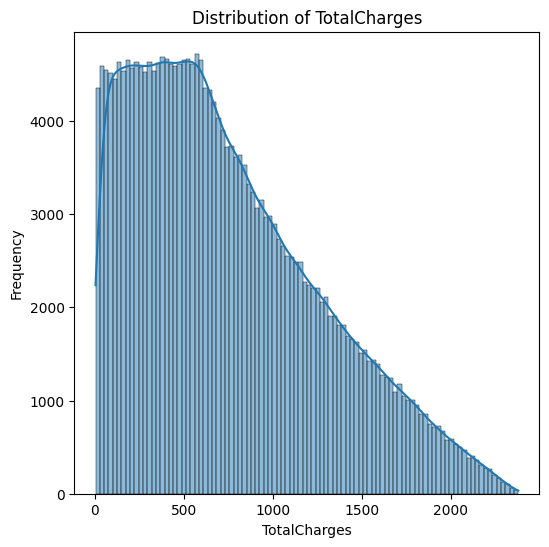

Mean of TotalCharges: 750.7410172504389
Median of TotalCharges: 649.8784870885065


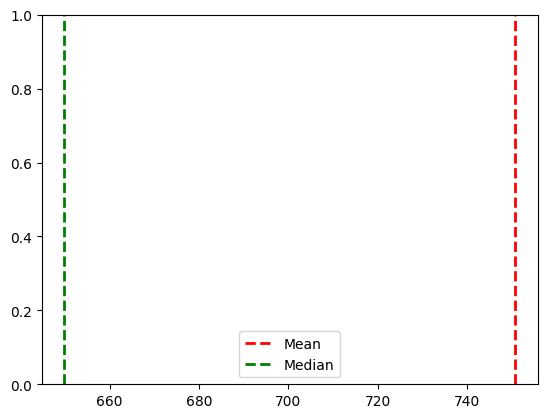

In [25]:
plot_histogram(df, 'TotalCharges')

Box plot for Numerical Features

In [26]:
def plot_boxplot(df, column_name):
  plt.figure(figsize=(6, 6))
  sns.boxplot(x=column_name, data=df)
  plt.title(f"Boxplot of {column_name}")
  plt.xlabel(column_name)
  plt.ylabel("Frequency")
  plt.show()

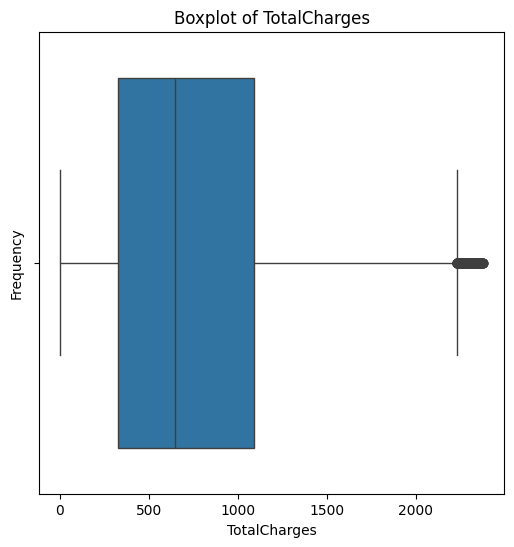

In [27]:
plot_boxplot(df, 'TotalCharges')

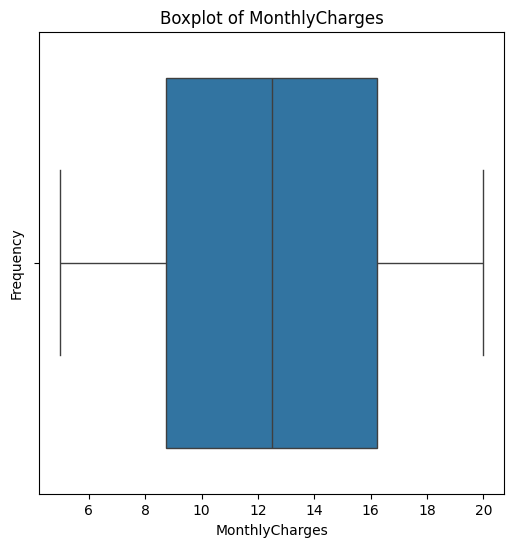

In [28]:
plot_boxplot(df, 'MonthlyCharges')

Coorelation Heatmap of the Numerical Feautures

In [29]:
# correlation matrix - heatmap

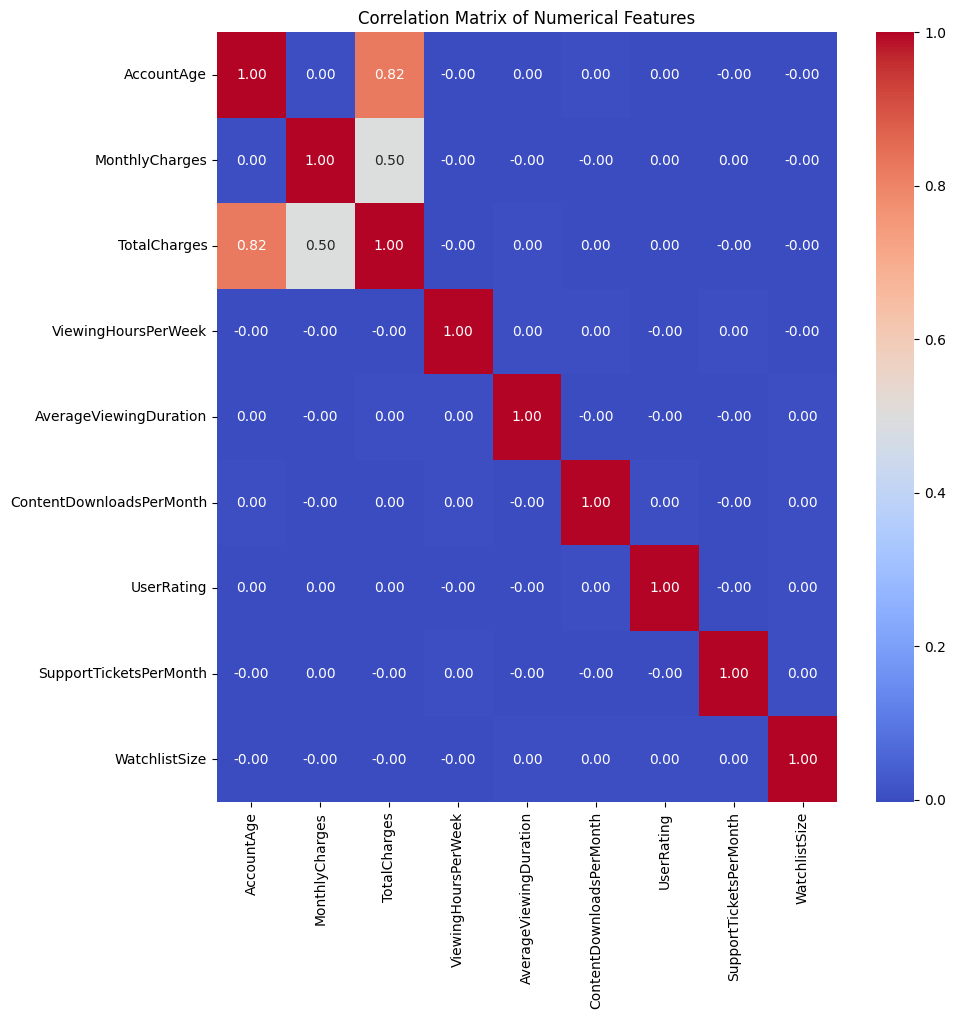

In [30]:
plt.figure(figsize=(10, 10))
sns.heatmap(df[["AccountAge",	"MonthlyCharges",	"TotalCharges",	"ViewingHoursPerWeek",	"AverageViewingDuration",	"ContentDownloadsPerMonth",	"UserRating", "SupportTicketsPerMonth",	"WatchlistSize"]].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Numerical Features")
plt.show()

In [31]:
# Re-loading the DataFrame and dropping 'CustomerID' to ensure df is defined
df = pd.read_csv("/content/train.csv")
df = df.drop(columns=['CustomerID'])

## Categorical Features Analysis

In [32]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
# Exclude 'CustomerID' since it was dropped, but ensure it's not in the list just in case
if 'CustomerID' in categorical_cols:
    categorical_cols.remove('CustomerID')

print(f"Categorical columns: {categorical_cols}")

Categorical columns: ['SubscriptionType', 'PaymentMethod', 'PaperlessBilling', 'ContentType', 'MultiDeviceAccess', 'DeviceRegistered', 'GenrePreference', 'Gender', 'ParentalControl', 'SubtitlesEnabled']


Understand the distribution of the categorical features.

In [33]:
def plot_categorical_distribution(df, column_name):
  plt.figure(figsize=(8, 6))
  sns.countplot(data=df, x=column_name, hue=column_name, palette='viridis', legend=False)
  plt.title(f'Distribution of {column_name}')
  plt.xlabel(column_name)
  plt.ylabel('Count')
  plt.xticks(rotation=45, ha='right')
  plt.tight_layout()
  plt.show()

  print(df[column_name].value_counts())
  print('\nPercentage of each category:')
  print(df[column_name].value_counts(normalize=True) * 100)

In [34]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
# Exclude 'CustomerID' since it was dropped, but ensure it's not in the list just in case
if 'CustomerID' in categorical_cols:
    categorical_cols.remove('CustomerID')

print(f"Categorical columns: {categorical_cols}")

Categorical columns: ['SubscriptionType', 'PaymentMethod', 'PaperlessBilling', 'ContentType', 'MultiDeviceAccess', 'DeviceRegistered', 'GenrePreference', 'Gender', 'ParentalControl', 'SubtitlesEnabled']


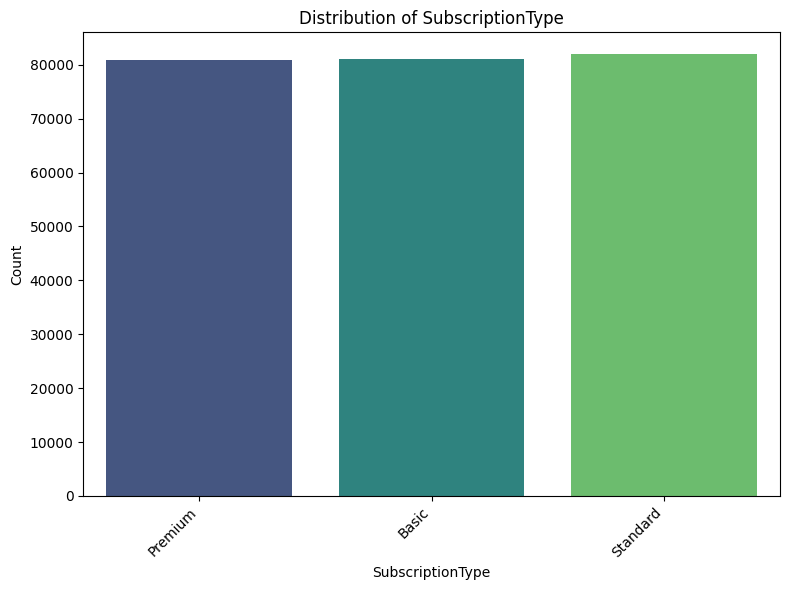

SubscriptionType
Standard    81920
Basic       81050
Premium     80817
Name: count, dtype: int64

Percentage of each category:
SubscriptionType
Standard    33.603104
Basic       33.246235
Premium     33.150660
Name: proportion, dtype: float64


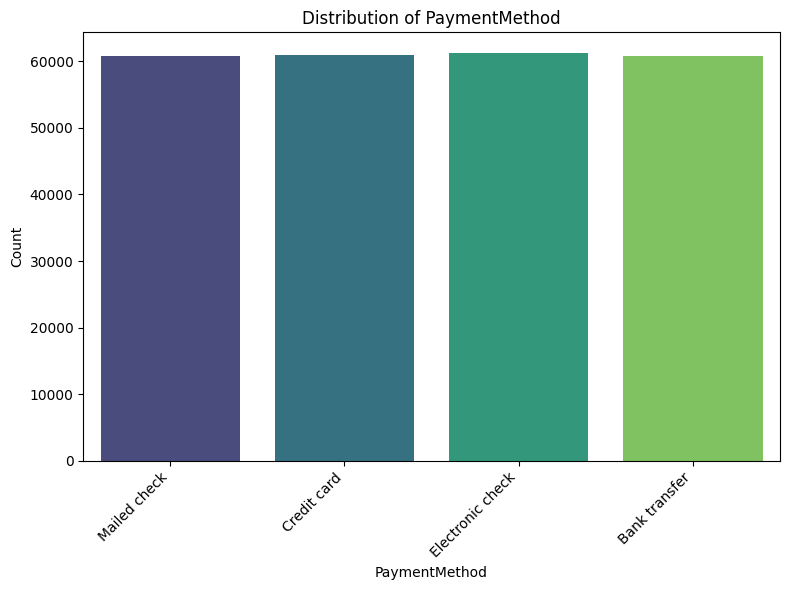

PaymentMethod
Electronic check    61313
Credit card         60924
Bank transfer       60797
Mailed check        60753
Name: count, dtype: int64

Percentage of each category:
PaymentMethod
Electronic check    25.150234
Credit card         24.990668
Bank transfer       24.938573
Mailed check        24.920525
Name: proportion, dtype: float64


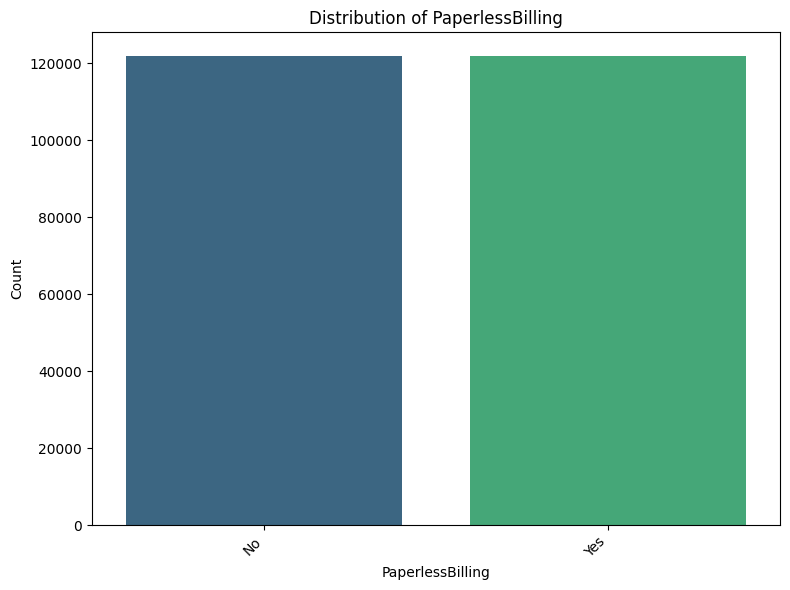

PaperlessBilling
No     121980
Yes    121807
Name: count, dtype: int64

Percentage of each category:
PaperlessBilling
No     50.035482
Yes    49.964518
Name: proportion, dtype: float64


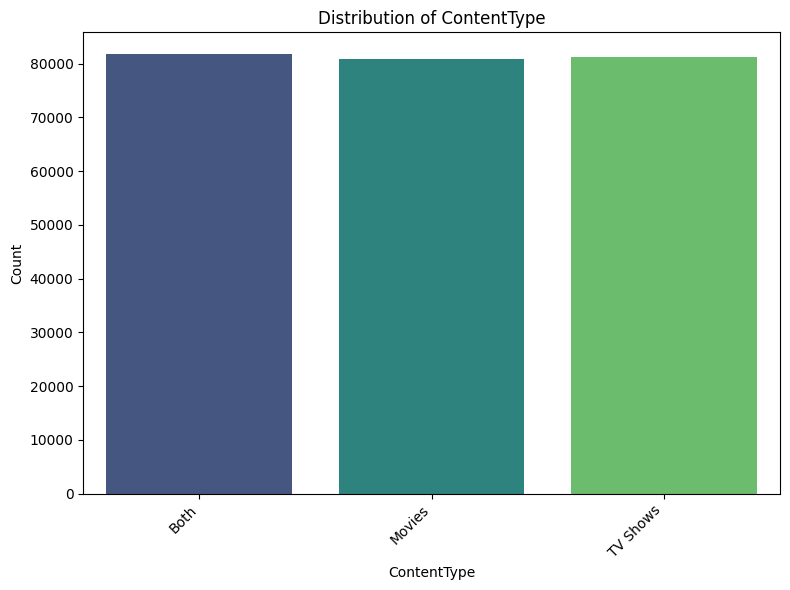

ContentType
Both        81737
TV Shows    81145
Movies      80905
Name: count, dtype: int64

Percentage of each category:
ContentType
Both        33.528039
TV Shows    33.285204
Movies      33.186757
Name: proportion, dtype: float64


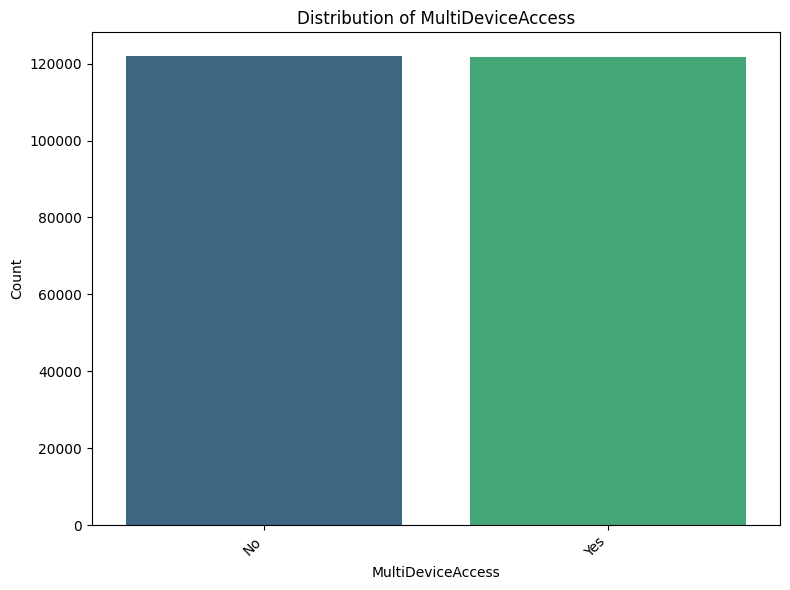

MultiDeviceAccess
No     122035
Yes    121752
Name: count, dtype: int64

Percentage of each category:
MultiDeviceAccess
No     50.058042
Yes    49.941958
Name: proportion, dtype: float64


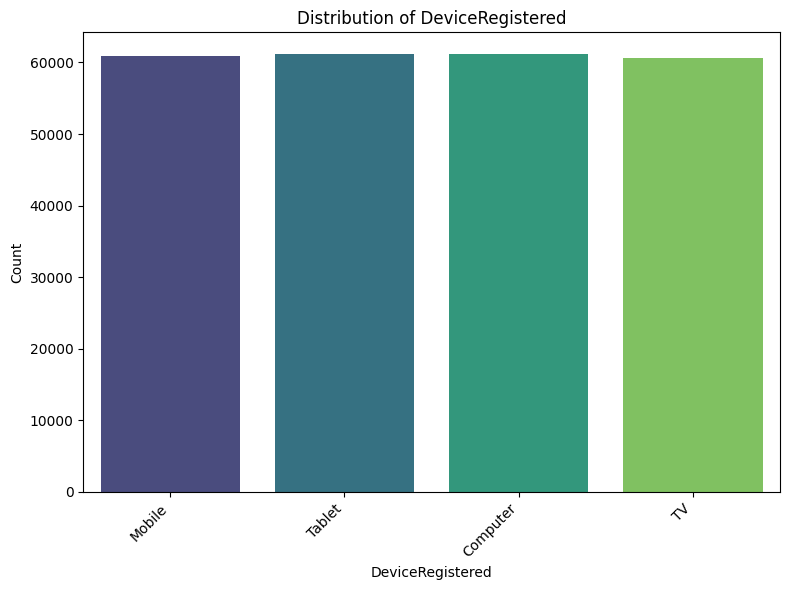

DeviceRegistered
Computer    61147
Tablet      61143
Mobile      60914
TV          60583
Name: count, dtype: int64

Percentage of each category:
DeviceRegistered
Computer    25.082141
Tablet      25.080501
Mobile      24.986566
TV          24.850792
Name: proportion, dtype: float64


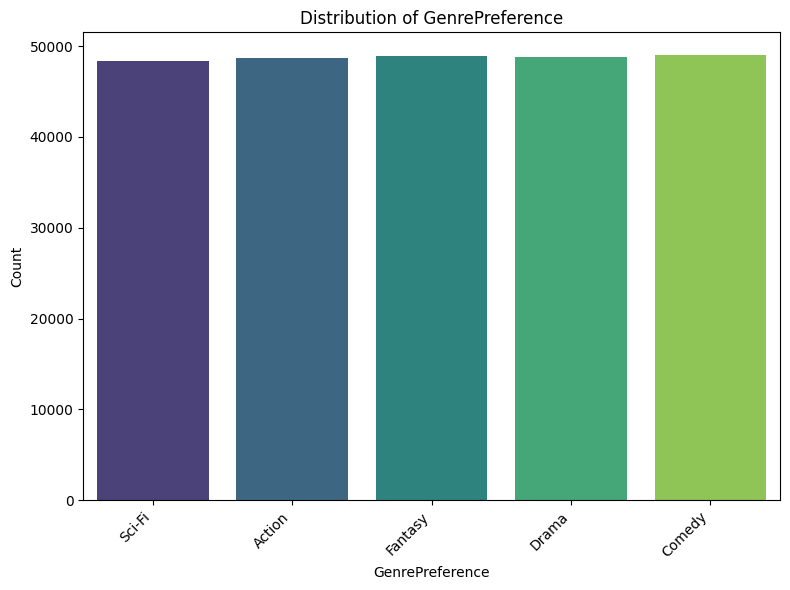

GenrePreference
Comedy     49060
Fantasy    48955
Drama      48744
Action     48690
Sci-Fi     48338
Name: count, dtype: int64

Percentage of each category:
GenrePreference
Comedy     20.124125
Fantasy    20.081054
Drama      19.994503
Action     19.972353
Sci-Fi     19.827965
Name: proportion, dtype: float64


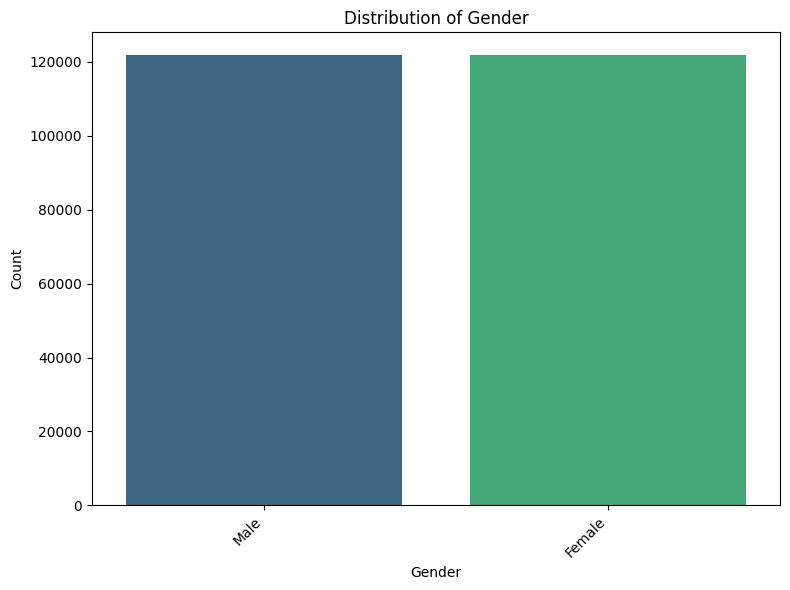

Gender
Female    121930
Male      121857
Name: count, dtype: int64

Percentage of each category:
Gender
Female    50.014972
Male      49.985028
Name: proportion, dtype: float64


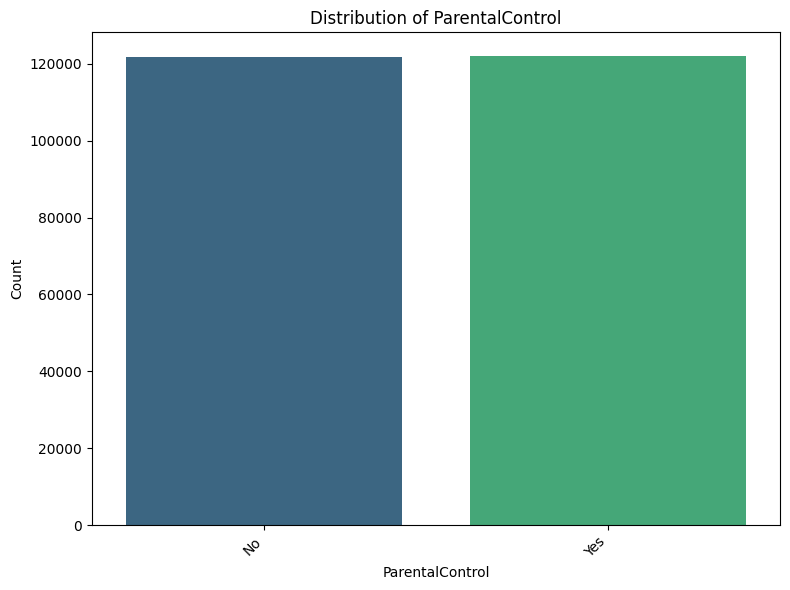

ParentalControl
Yes    122085
No     121702
Name: count, dtype: int64

Percentage of each category:
ParentalControl
Yes    50.078552
No     49.921448
Name: proportion, dtype: float64


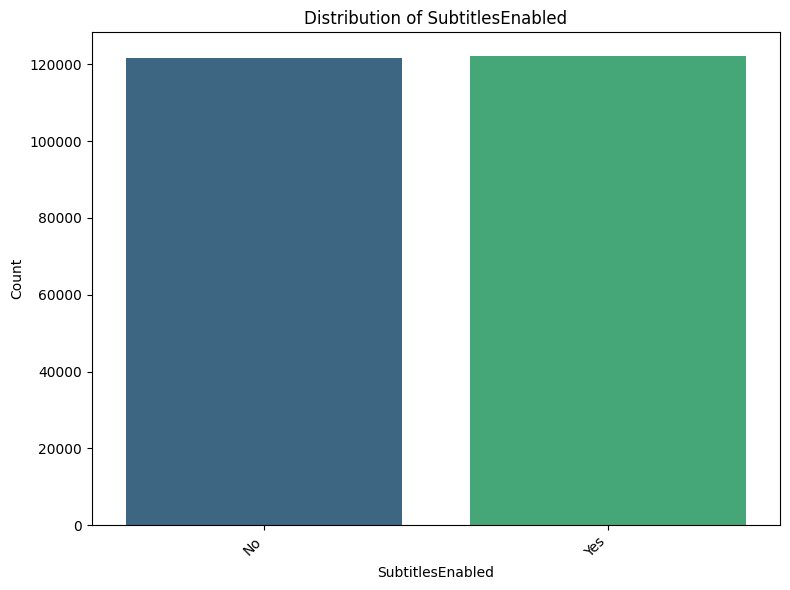

SubtitlesEnabled
Yes    122180
No     121607
Name: count, dtype: int64

Percentage of each category:
SubtitlesEnabled
Yes    50.117521
No     49.882479
Name: proportion, dtype: float64


In [35]:
for col in categorical_cols:
  plot_categorical_distribution(df, col)

## Data Preprocessing for Model Training

In [36]:
# Separate features (X) and target (y)
X = df.drop('Churn', axis=1)
y = df['Churn']

# Apply one-hot encoding to categorical features
X = pd.get_dummies(X, drop_first=True)

In [37]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Original training set size: {X_train.shape[0]}")
print(f"Original testing set size: {X_test.shape[0]}")
print(f"Churn distribution in training set:\n{y_train.value_counts(normalize=True)}")
print(f"Churn distribution in testing set:\n{y_test.value_counts(normalize=True)}")

Original training set size: 195029
Original testing set size: 48758
Churn distribution in training set:
Churn
0    0.818771
1    0.181229
Name: proportion, dtype: float64
Churn distribution in testing set:
Churn
0    0.818758
1    0.181242
Name: proportion, dtype: float64


## Handling Class Imbalance with SMOTE

In [38]:
# Apply SMOTE to the training data
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"Resampled training set size: {X_train_resampled.shape[0]}")
print(f"Churn distribution in resampled training set:\n{y_train_resampled.value_counts(normalize=True)}")

Resampled training set size: 319368
Churn distribution in resampled training set:
Churn
0    0.5
1    0.5
Name: proportion, dtype: float64


## Model Training and Evaluation

In [39]:
# Train a RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced')
rf_model.fit(X_train_resampled, y_train_resampled)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
print("Random Forest Classifier Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Classifier Performance:
Accuracy: 0.8013

Confusion Matrix:
[[37211  2710]
 [ 6980  1857]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.93      0.88     39921
           1       0.41      0.21      0.28      8837

    accuracy                           0.80     48758
   macro avg       0.62      0.57      0.58     48758
weighted avg       0.76      0.80      0.77     48758



## Generating Predictions on `test.csv`

In [42]:
# Load the test data
try:
    df_test = pd.read_csv("/content/test.csv")
except FileNotFoundError:
    print("Error: test.csv not found. Please upload the file to /content/test.csv or provide the correct path.")
    raise

# Save CustomerID for the final submission file
test_customer_ids = df_test['CustomerID']

# Drop CustomerID from the test set for preprocessing
if 'CustomerID' in df_test.columns:
    df_test = df_test.drop(columns=['CustomerID'])

# Apply one-hot encoding to categorical features in the test set
# This creates new columns for each category and ensures consistency with training data
X_test_processed = pd.get_dummies(df_test, drop_first=True)

# Align columns with the training data's columns (X_train)
# Add missing columns with 0s and reorder columns to match X_train
missing_cols_in_test = set(X_train.columns) - set(X_test_processed.columns)
for c in missing_cols_in_test:
    X_test_processed[c] = 0

# Ensure the order of columns in the test set is the same as in the training set
X_test_processed = X_test_processed[X_train.columns]

print(f"Processed test set shape: {X_test_processed.shape}")

Processed test set shape: (104480, 28)


In [43]:
# Make predictions (predicted probabilities of churn)
# rf_model.predict_proba returns probabilities for both classes [P(class 0), P(class 1)]
# We want the probability of churn (class 1), which is the second column.
predicted_probabilities = rf_model.predict_proba(X_test_processed)[:, 1]

# Create the prediction_df DataFrame
prediction_df = pd.DataFrame({
    'CustomerID': test_customer_ids,
    'predicted_probability': predicted_probabilities
})

# Display the first few rows of the prediction_df
display(prediction_df.head())

# Check the shape of the prediction_df
print(f"Shape of prediction_df: {prediction_df.shape}")

,CustomerID,predicted_probability
0,O1W6BHP6RM,0.11
1,LFR4X92X8H,0.09
2,QM5GBIYODA,0.32
3,D9RXTK2K9F,0.15
4,ENTCCHR1LR,0.23


Shape of prediction_df: (104480, 2)


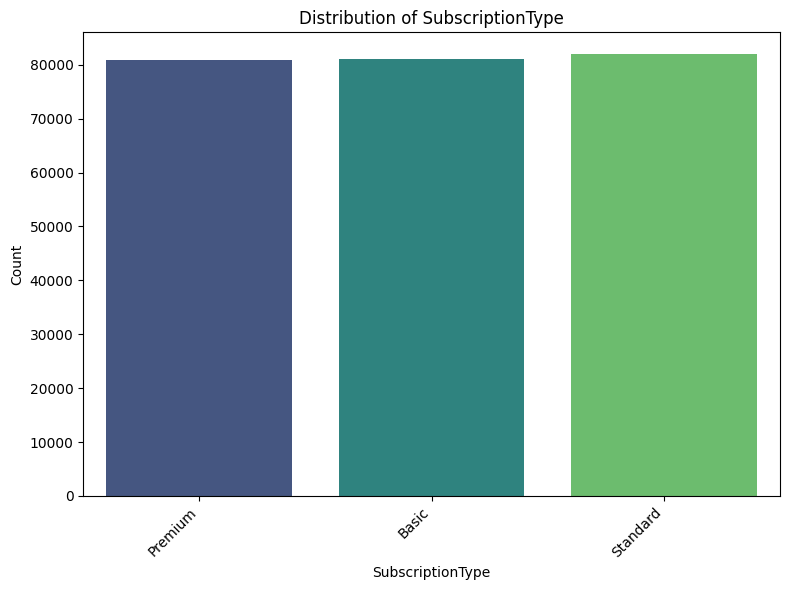

SubscriptionType
Standard    81920
Basic       81050
Premium     80817
Name: count, dtype: int64

Percentage of each category:
SubscriptionType
Standard    33.603104
Basic       33.246235
Premium     33.150660
Name: proportion, dtype: float64


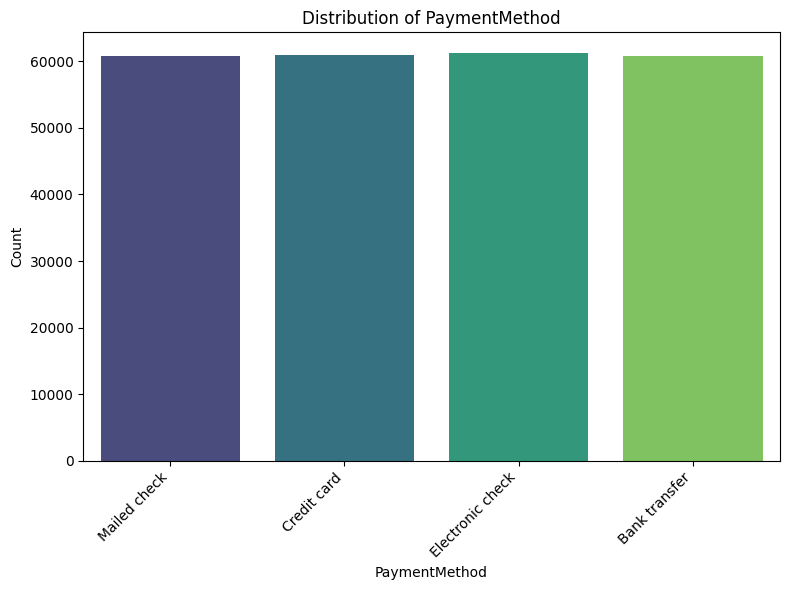

PaymentMethod
Electronic check    61313
Credit card         60924
Bank transfer       60797
Mailed check        60753
Name: count, dtype: int64

Percentage of each category:
PaymentMethod
Electronic check    25.150234
Credit card         24.990668
Bank transfer       24.938573
Mailed check        24.920525
Name: proportion, dtype: float64


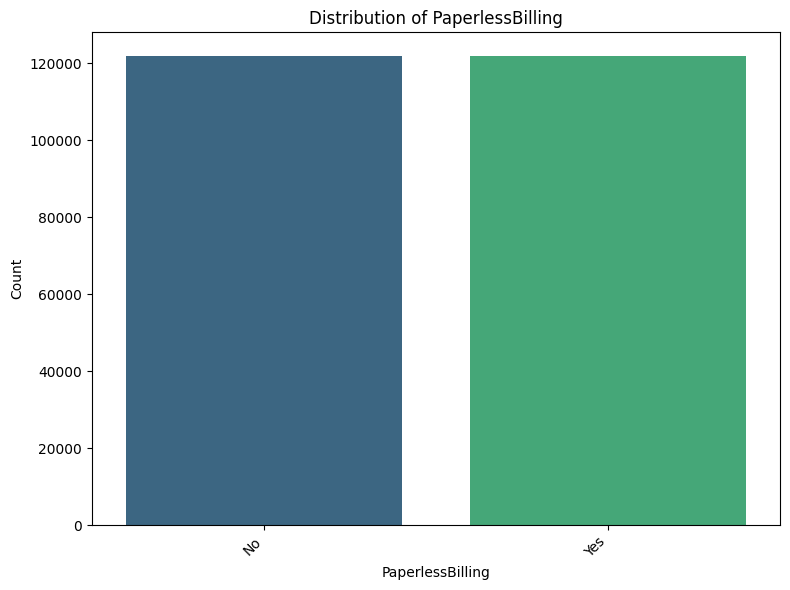

PaperlessBilling
No     121980
Yes    121807
Name: count, dtype: int64

Percentage of each category:
PaperlessBilling
No     50.035482
Yes    49.964518
Name: proportion, dtype: float64


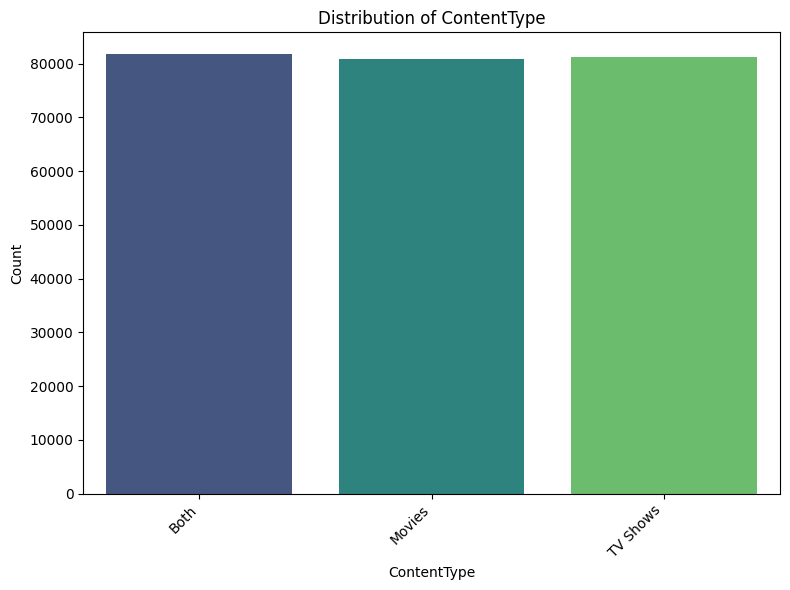

ContentType
Both        81737
TV Shows    81145
Movies      80905
Name: count, dtype: int64

Percentage of each category:
ContentType
Both        33.528039
TV Shows    33.285204
Movies      33.186757
Name: proportion, dtype: float64


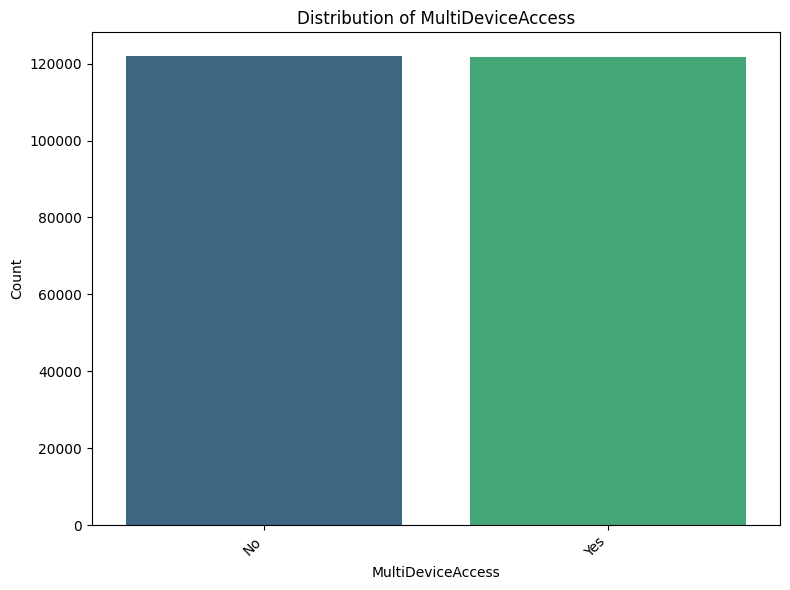

MultiDeviceAccess
No     122035
Yes    121752
Name: count, dtype: int64

Percentage of each category:
MultiDeviceAccess
No     50.058042
Yes    49.941958
Name: proportion, dtype: float64


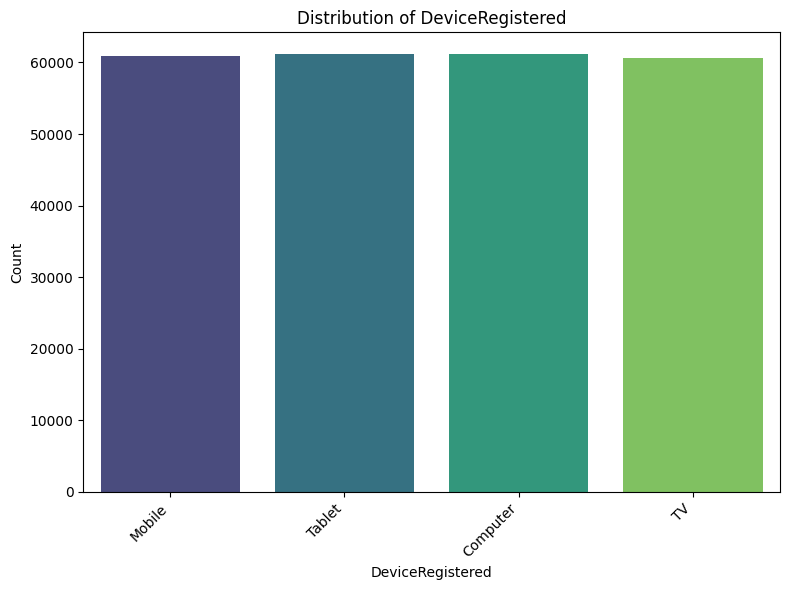

DeviceRegistered
Computer    61147
Tablet      61143
Mobile      60914
TV          60583
Name: count, dtype: int64

Percentage of each category:
DeviceRegistered
Computer    25.082141
Tablet      25.080501
Mobile      24.986566
TV          24.850792
Name: proportion, dtype: float64


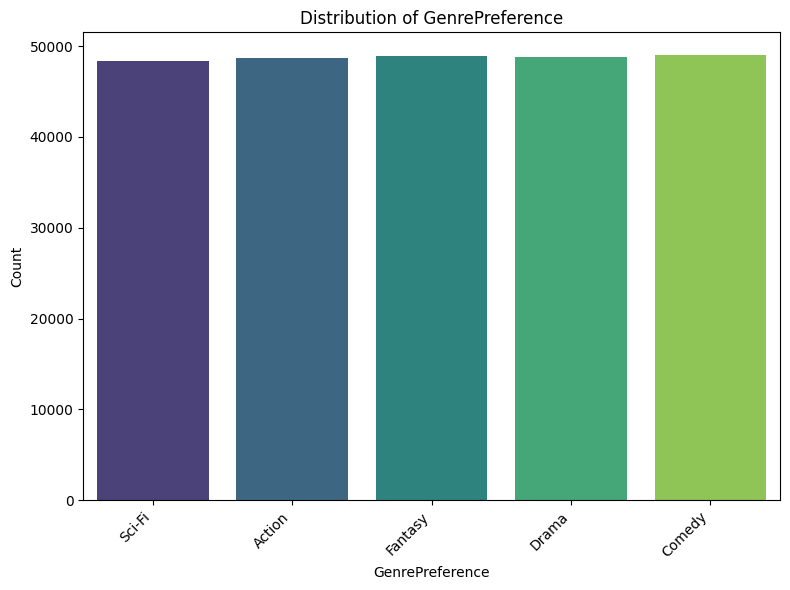

GenrePreference
Comedy     49060
Fantasy    48955
Drama      48744
Action     48690
Sci-Fi     48338
Name: count, dtype: int64

Percentage of each category:
GenrePreference
Comedy     20.124125
Fantasy    20.081054
Drama      19.994503
Action     19.972353
Sci-Fi     19.827965
Name: proportion, dtype: float64


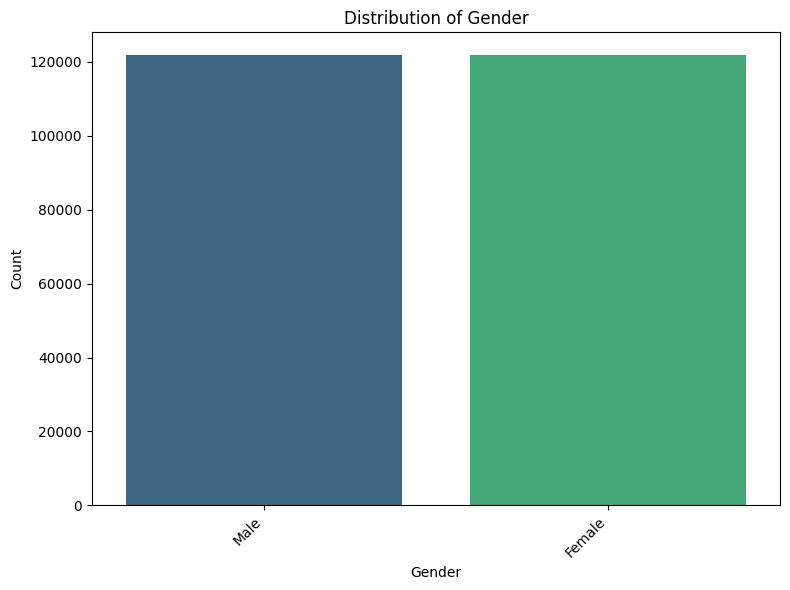

Gender
Female    121930
Male      121857
Name: count, dtype: int64

Percentage of each category:
Gender
Female    50.014972
Male      49.985028
Name: proportion, dtype: float64


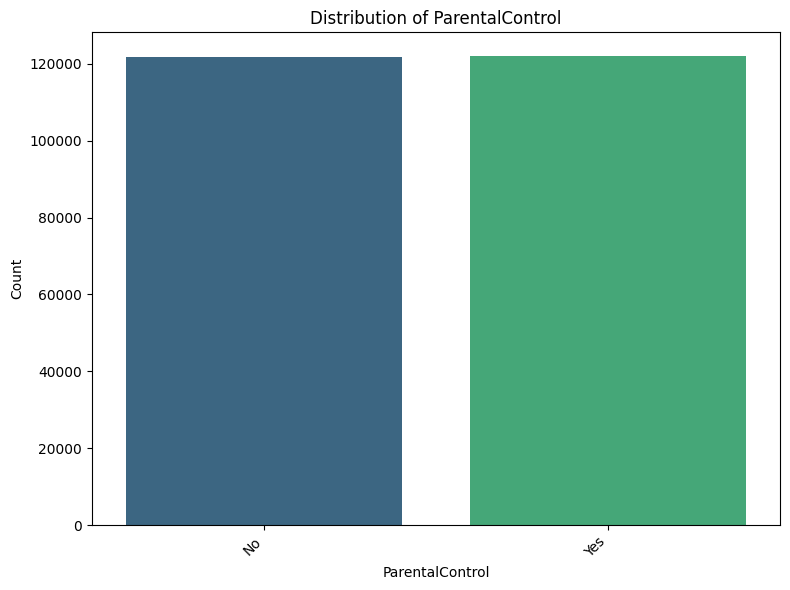

ParentalControl
Yes    122085
No     121702
Name: count, dtype: int64

Percentage of each category:
ParentalControl
Yes    50.078552
No     49.921448
Name: proportion, dtype: float64


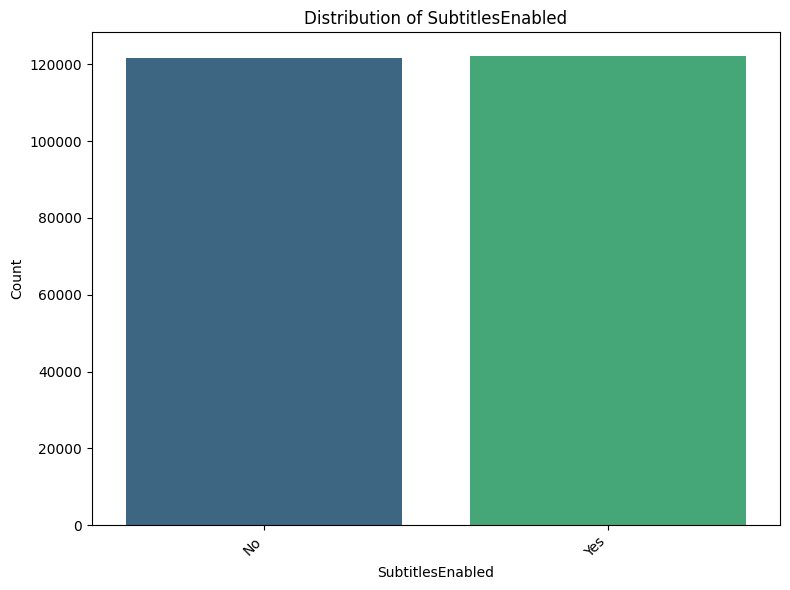

SubtitlesEnabled
Yes    122180
No     121607
Name: count, dtype: int64

Percentage of each category:
SubtitlesEnabled
Yes    50.117521
No     49.882479
Name: proportion, dtype: float64


In [40]:
for col in categorical_cols:
  plot_categorical_distribution(df, col)